In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
DATA_PATH = r"data/infosys/INFY.csv"
COMPANY_NAME = "Infosys"

df = pd.read_csv(DATA_PATH)
df["Date"] = pd.to_datetime(df["Date"])
df.head()

,Date,Adj Close,Close,High,Low,Open,Volume
0,2015-01-01,359.980988,493.600006,495.500000,489.225006,492.237488,2002764
1,2015-01-02,367.055298,503.299988,504.762512,493.000000,493.000000,6778320
2,2015-01-05,363.901062,498.975006,507.500000,494.375000,502.475006,9937024
3,2015-01-06,356.298096,488.549988,496.250000,483.524994,495.000000,9667316
4,2015-01-07,358.002808,490.887512,493.687500,487.500000,491.250000,7249916


General

In [5]:
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nDate range:")
print(df["Date"].min(), "to", df["Date"].max())

Shape: (2898, 7)

Columns:
['Date', 'Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume']

Data types:
Date         datetime64[us]
Adj Close           float64
Close               float64
High                float64
Low                 float64
Open                float64
Volume                int64
dtype: object

Date range:
2015-01-01 00:00:00 to 2026-09-21 00:00:00


Trend

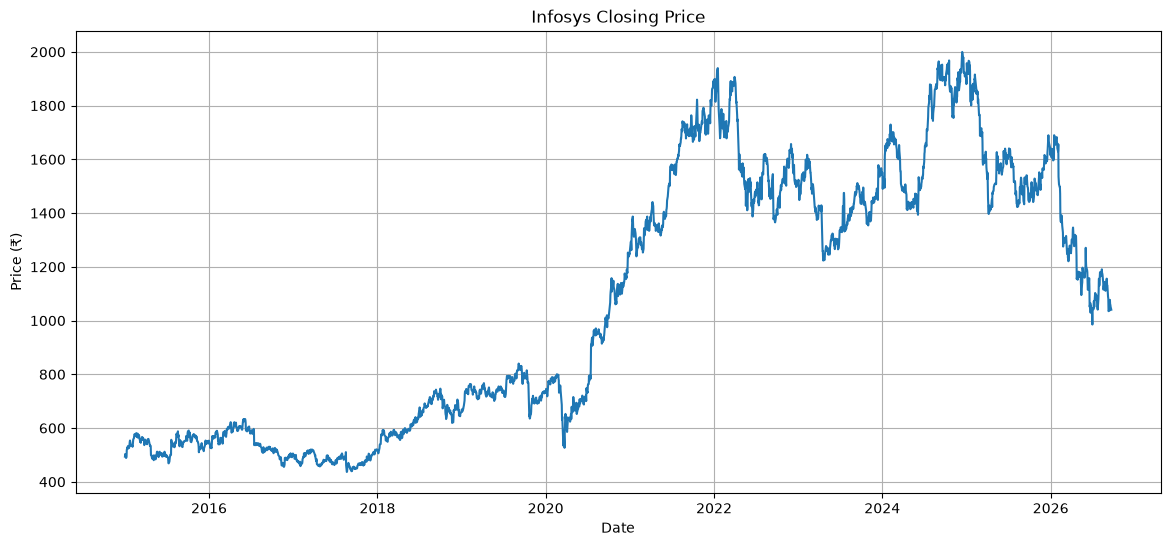

In [6]:
plt.figure(figsize=(14, 6))
plt.plot(df["Date"], df["Close"])
plt.title(f"{COMPANY_NAME} Closing Price")
plt.xlabel("Date")
plt.ylabel("Price (₹)")
plt.grid(True)
plt.show()

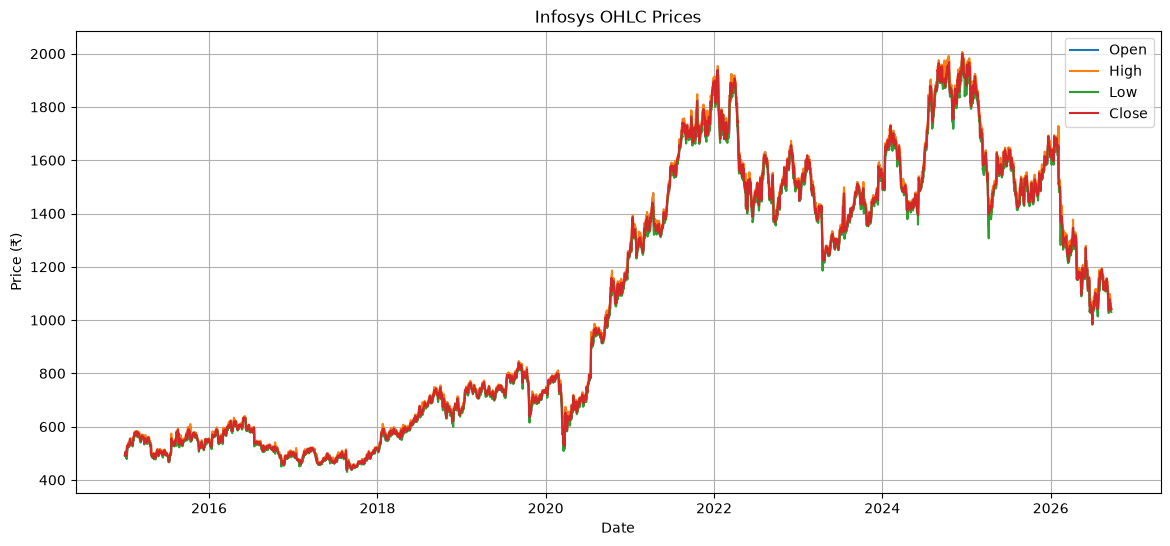

In [7]:
plt.figure(figsize=(14, 6))

plt.plot(df["Date"], df["Open"], label="Open")
plt.plot(df["Date"], df["High"], label="High")
plt.plot(df["Date"], df["Low"], label="Low")
plt.plot(df["Date"], df["Close"], label="Close")

plt.title(f"{COMPANY_NAME} OHLC Prices")
plt.xlabel("Date")
plt.ylabel("Price (₹)")
plt.legend()
plt.grid(True)
plt.show()

Volume

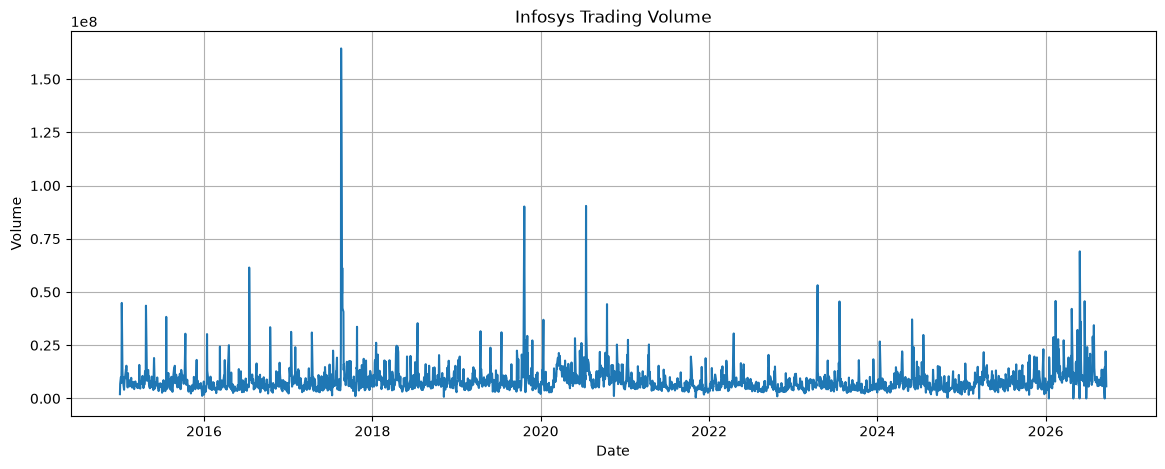

In [8]:
plt.figure(figsize=(14, 5))

plt.plot(df["Date"], df["Volume"])

plt.title(f"{COMPANY_NAME} Trading Volume")
plt.xlabel("Date")
plt.ylabel("Volume")
plt.grid(True)
plt.show()

In [9]:
df["Volume"].describe()

count    2.898000e+03
mean     8.263073e+06
std      6.740118e+06
min      0.000000e+00
25%      5.090316e+06
50%      6.801876e+06
75%      9.248153e+06
max      1.644050e+08
Name: Volume, dtype: float64

Returns

In [10]:
df["Return"] = df["Close"].pct_change()

df[["Date", "Close", "Return"]].head(10)

,Date,Close,Return
0,2015-01-01,493.600006,NaN
1,2015-01-02,503.299988,0.019652
2,2015-01-05,498.975006,-0.008593
3,2015-01-06,488.549988,-0.020893
4,2015-01-07,490.887512,0.004785
5,2015-01-08,493.362488,0.005042
6,2015-01-09,518.612488,0.051179
7,2015-01-12,528.987488,0.020005
8,2015-01-13,522.224976,-0.012784
9,2015-01-14,532.162476,0.019029


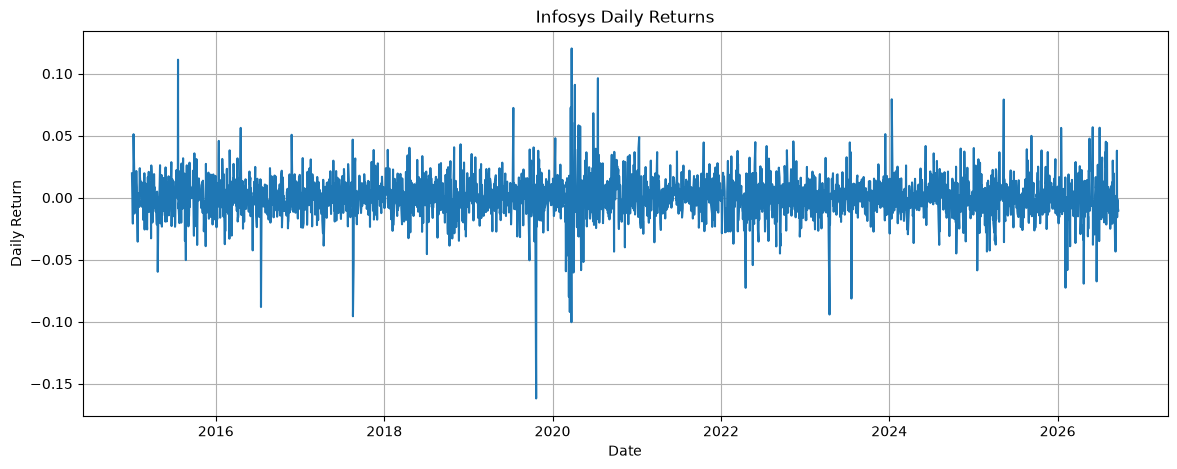

In [11]:
plt.figure(figsize=(14, 5))

plt.plot(df["Date"], df["Return"])

plt.title(f"{COMPANY_NAME} Daily Returns")
plt.xlabel("Date")
plt.ylabel("Daily Return")
plt.grid(True)
plt.show()

In [12]:
df["Return"].describe()

count    2897.000000
mean        0.000402
std         0.016946
min        -0.161881
25%        -0.008531
50%         0.000196
75%         0.009570
max         0.120334
Name: Return, dtype: float64

Annual Volatility

In [13]:
annual_volatility = df["Return"].std() * np.sqrt(252)

print(f"Annualized volatility: {annual_volatility:.2%}")

Annualized volatility: 26.90%


Simple Moving Averages

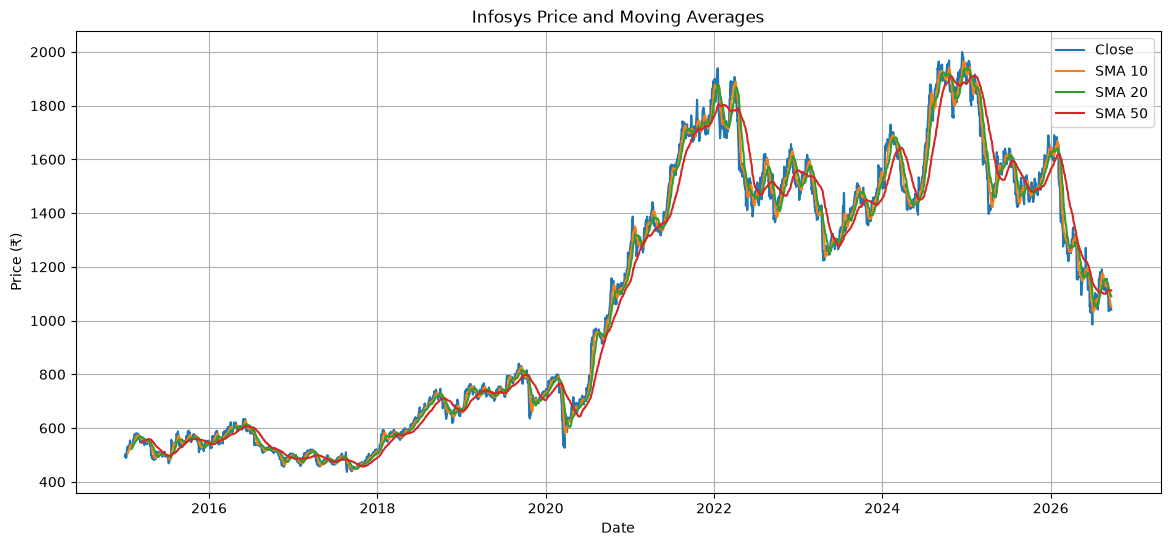

In [14]:
df["SMA_10"] = df["Close"].rolling(10).mean()
df["SMA_20"] = df["Close"].rolling(20).mean()
df["SMA_50"] = df["Close"].rolling(50).mean()

plt.figure(figsize=(14, 6))

plt.plot(df["Date"], df["Close"], label="Close")
plt.plot(df["Date"], df["SMA_10"], label="SMA 10")
plt.plot(df["Date"], df["SMA_20"], label="SMA 20")
plt.plot(df["Date"], df["SMA_50"], label="SMA 50")

plt.title(f"{COMPANY_NAME} Price and Moving Averages")
plt.xlabel("Date")
plt.ylabel("Price (₹)")
plt.legend()
plt.grid(True)
plt.show()

Exponential Moving Averages

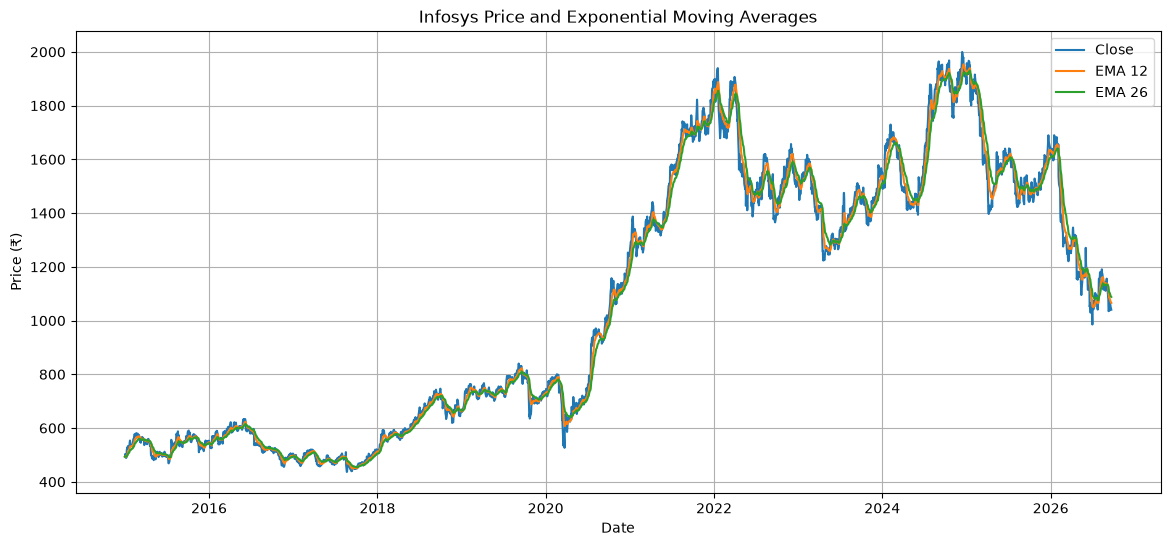

In [15]:
df["EMA_12"] = df["Close"].ewm(span=12, adjust=False).mean()
df["EMA_26"] = df["Close"].ewm(span=26, adjust=False).mean()

plt.figure(figsize=(14, 6))

plt.plot(df["Date"], df["Close"], label="Close")
plt.plot(df["Date"], df["EMA_12"], label="EMA 12")
plt.plot(df["Date"], df["EMA_26"], label="EMA 26")

plt.title(f"{COMPANY_NAME} Price and Exponential Moving Averages")
plt.xlabel("Date")
plt.ylabel("Price (₹)")
plt.legend()
plt.grid(True)
plt.show()

Twenty Day Rolling Volitality

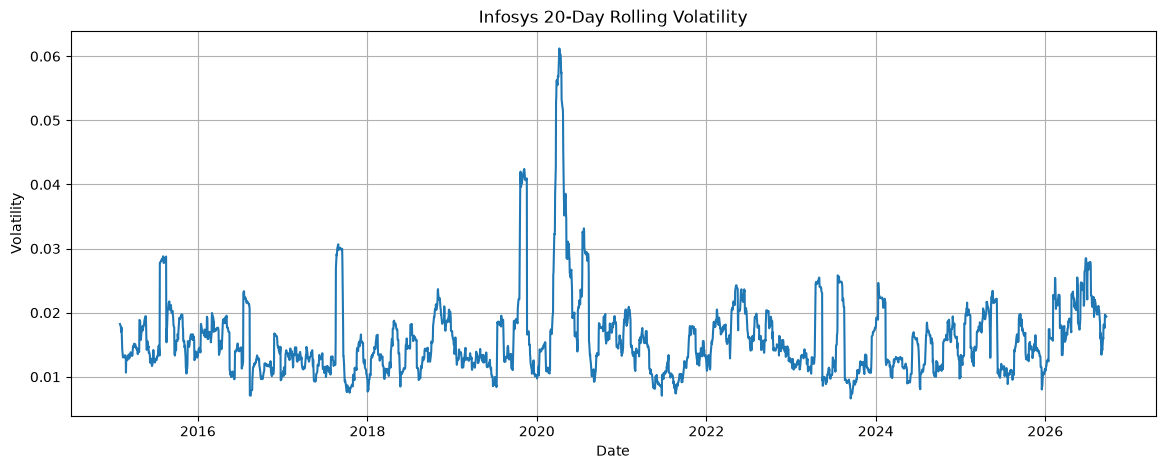

In [16]:
df["Volatility_20"] = df["Return"].rolling(20).std()

plt.figure(figsize=(14, 5))

plt.plot(df["Date"], df["Volatility_20"])

plt.title(f"{COMPANY_NAME} 20-Day Rolling Volatility")
plt.xlabel("Date")
plt.ylabel("Volatility")
plt.grid(True)
plt.show()

Correlation

In [17]:
features = [
    "Open",
    "High",
    "Low",
    "Close",
    "Volume",
    "Return",
    "SMA_10",
    "SMA_20",
    "SMA_50",
    "EMA_12",
    "EMA_26",
    "Volatility_20",
]

df[features].corr()

,Open,High,Low,Close,Volume,Return,SMA_10,SMA_20,SMA_50,EMA_12,EMA_26,Volatility_20
Open,1.000000,0.999762,0.999766,0.999531,-0.125822,-0.016074,0.998139,0.995568,0.987119,0.998330,0.995588,-0.091050
High,0.999762,1.000000,0.999747,0.999821,-0.120320,-0.003695,0.998078,0.995565,0.987282,0.998303,0.995616,-0.087338
Low,0.999766,0.999747,1.000000,0.999809,-0.131596,-0.003376,0.997884,0.995251,0.986717,0.998102,0.995278,-0.093974
Close,0.999531,0.999821,0.999809,1.000000,-0.126375,0.006164,0.997796,0.995194,0.986764,0.998037,0.995240,-0.091021
Volume,-0.125822,-0.120320,-0.131596,-0.126375,1.000000,-0.064619,-0.119464,-0.115510,-0.108142,-0.120678,-0.115900,0.291268
Return,-0.016074,-0.003695,-0.003376,0.006164,-0.064619,1.000000,-0.024285,-0.025584,-0.025975,-0.023797,-0.026610,0.009593
SMA_10,0.998139,0.998078,0.997884,0.997796,-0.119464,-0.024285,1.000000,0.998710,0.991199,0.999865,0.998423,-0.087619
SMA_20,0.995568,0.995565,0.995251,0.995194,-0.115510,-0.025584,0.998710,1.000000,0.995000,0.999123,0.999659,-0.079884
SMA_50,0.987119,0.987282,0.986717,0.986764,-0.108142,-0.025975,0.991199,0.995000,1.000000,0.992452,0.996842,-0.058335
EMA_12,0.998330,0.998303,0.998102,0.998037,-0.120678,-0.023797,0.999865,0.999123,0.992452,1.000000,0.998962,-0.085433


<Axes: >

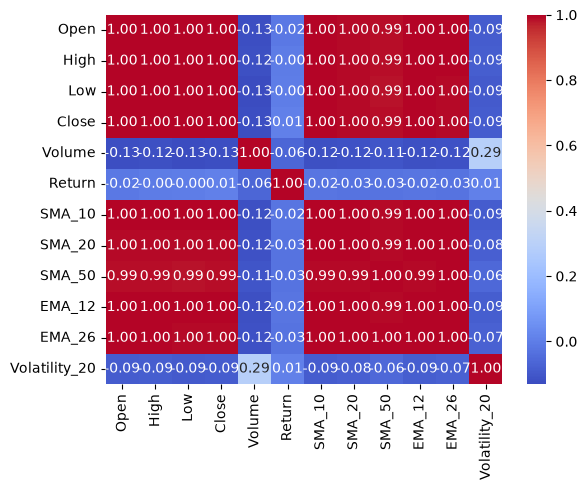

In [18]:
sns.heatmap(df[features].corr(), annot=True, fmt=".2f", cmap="coolwarm", cbar=True)

In [19]:
df.tail()

,Date,Adj Close,Close,High,Low,Open,Volume,Return,SMA_10,SMA_20,SMA_50,EMA_12,EMA_26,Volatility_20
2893,2026-09-15,1077.000000,1077.000000,1097.699951,1071.699951,1085.000000,14816117,0.037872,1079.369995,1105.155005,1113.582000,1079.657039,1101.026219,0.019504
2894,2026-09-16,1060.000000,1060.000000,1085.099976,1053.500000,1082.500000,6230590,-0.015785,1071.369995,1102.165002,1113.395999,1076.632879,1097.987240,0.019702
2895,2026-09-17,1058.599976,1058.599976,1063.599976,1048.599976,1054.900024,5469865,-0.001321,1064.199988,1098.595001,1113.551997,1073.858586,1095.069664,0.019515
2896,2026-09-18,1051.400024,1051.400024,1061.900024,1038.000000,1061.900024,22124953,-0.006801,1056.339990,1095.115002,1113.219998,1070.403423,1091.834876,0.019501
2897,2026-09-21,1040.500000,1040.500000,1044.500000,1030.300049,1041.500000,5740202,-0.010367,1051.639990,1090.640002,1111.977998,1065.802896,1088.032293,0.019386


In [20]:
df[features].describe().T

,count,mean,std,min,25%,50%,75%,max
Open,2898.0,1.072813e+03,4.838914e+02,440.000000,5.837875e+02,1.069000e+03,1.510000e+03,1.995450e+03
High,2898.0,1.083372e+03,4.879154e+02,443.799988,5.909188e+02,1.082800e+03,1.521000e+03,2.006450e+03
Low,2898.0,1.061699e+03,4.795834e+02,430.000000,5.770063e+02,1.057250e+03,1.496175e+03,1.977600e+03
Close,2898.0,1.072415e+03,4.837955e+02,436.700012,5.837625e+02,1.070550e+03,1.508550e+03,1.999700e+03
Volume,2898.0,8.263073e+06,6.740118e+06,0.000000,5.090316e+06,6.801876e+06,9.248153e+06,1.644050e+08
Return,2897.0,4.015519e-04,1.694593e-02,-0.161881,-8.530666e-03,1.961861e-04,9.569750e-03,1.203343e-01
SMA_10,2889.0,1.073342e+03,4.833968e+02,446.245001,5.812250e+02,1.082430e+03,1.506235e+03,1.963785e+03
SMA_20,2879.0,1.074276e+03,4.830668e+02,449.093750,5.797562e+02,1.095115e+03,1.508320e+03,1.940243e+03
SMA_50,2849.0,1.076764e+03,4.820642e+02,456.263000,5.812940e+02,1.102444e+03,1.517766e+03,1.909986e+03
EMA_12,2898.0,1.071329e+03,4.833283e+02,448.871895,5.770302e+02,1.076905e+03,1.506838e+03,1.953467e+03
